# Important Links

<a href="https://colorhunt.co/">Color Hunt</a>

# Note

* This follows after 'D28-Challenge3'

### main.py 

In [1]:
# ---------------------------- CONSTANTS ------------------------------- #
PINK = "#e2979c"
RED = "#e7305b"
GREEN = "#9bdeac"
YELLOW = "#f7f5dd"
FONT_NAME = "Courier"
WORK_MIN = 25
SHORT_BREAK_MIN = 5
LONG_BREAK_MIN = 20

SET_FONT1 = (FONT_NAME, 35, "bold")
SET_FONT2 = (FONT_NAME, 50,)

#Challenge3
reps = 0

#challenge4
timer = None

In [2]:
import tkinter
from tkinter import *
import math

In [3]:
# ---------------------------- TIMER RESET ------------------------------- #

#Challenge4
def reset_timer():
    window.after_cancel(timer)
    canvas.itemconfig(timer_text, text="00:00")
    lbl_title.config(text="Timer")
    lbl_checks.config(text="")
    
    global reps
    reps = 0


# ---------------------------- TIMER MECHANISM ------------------------------- #
def start_timer():
    global reps
    reps += 1
    
    work_sec = WORK_MIN * 60
    short_break_sec = SHORT_BREAK_MIN * 60
    long_break_sec = LONG_BREAK_MIN * 60
    
    #If rep = 8
    if reps % 8 == 0:
        count_down(long_break_sec)
        lbl_title.config(text="Long Break", fg=RED)
    elif reps % 2 == 0:
        #If rep = 2/4/6
        count_down(short_break_sec)
        lbl_title.config(text="Short Break", fg=PINK)
    else:
        #If rep = 1/3/5/7
        count_down(work_sec)
        lbl_title.config(text="Work", fg=GREEN)

# ---------------------------- COUNTDOWN MECHANISM ------------------------------- #
def count_down(count):
    
    count_min = math.floor(count/60)
    count_sec = count%60
    
    #Dynamic Typing
    if count_sec < 10: 
        count_sec = f"0{count_sec}"
    
    canvas.itemconfig(timer_text, text=f"{count_min}:{count_sec}")
    if count > 0:
        global timer
        timer = window.after(1000, count_down, count-1)
    else:
        start_timer()
        
        #Challenge4
        marks = ""
        work_sessions = math.floor(reps/2)
        for _ in range(work_sessions):
            marks += "✔"
        lbl_checks.config(text=marks)

In [4]:
# ---------------------------- UI SETUP ------------------------------- #
window = Tk()
window.title("Pomodoro")
window.config(padx=100, pady=50, bg=YELLOW)

#Challenge1
#Label Widget
lbl_title = Label(text="Timer", fg=GREEN, bg=YELLOW, font=SET_FONT2) #fg=foreground, bg=background color

#Challenge4
lbl_checks = Label(fg=GREEN, bg=YELLOW)

#Canvas Widget
canvas = Canvas(width=200, height=224, bg=YELLOW, highlightthickness=0) #highlighthickness covers the white border between tomato and background of canvas

##PhotoImage
##attaches images to canvas
tomato_img = PhotoImage(file="tomato.png")

canvas.create_image(100, 112, image=tomato_img)
timer_text = canvas.create_text(100, 130, text="00:00", fill="white", font=SET_FONT1)

#Challenge1
#Button Widget
btn_start = Button(text="Start", highlightthickness=0, command=start_timer)
btn_reset = Button(text="Reset", highlightthickness=0, command=reset_timer)

#Challenge1
#Grid the widgets
canvas.grid(column=1, row=1)

lbl_title.grid(column=1, row=0)
lbl_checks.grid(column=1, row=3) #Challenge4

btn_start.grid(column=0, row=2)
btn_reset.grid(column=2, row=2)

#Display the app
window.mainloop()

### `start` button 

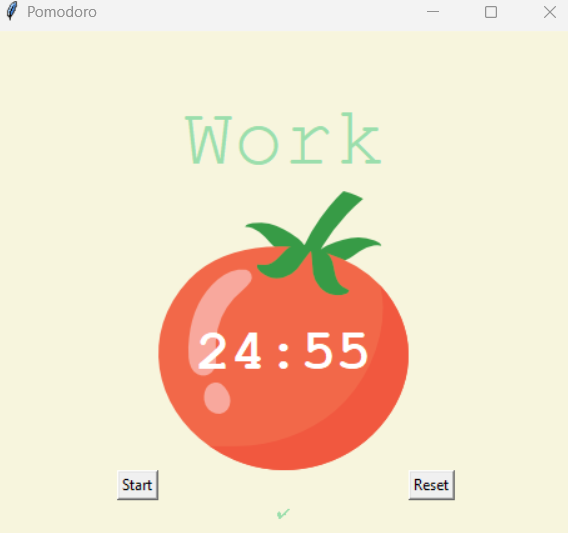

### `reset` button 

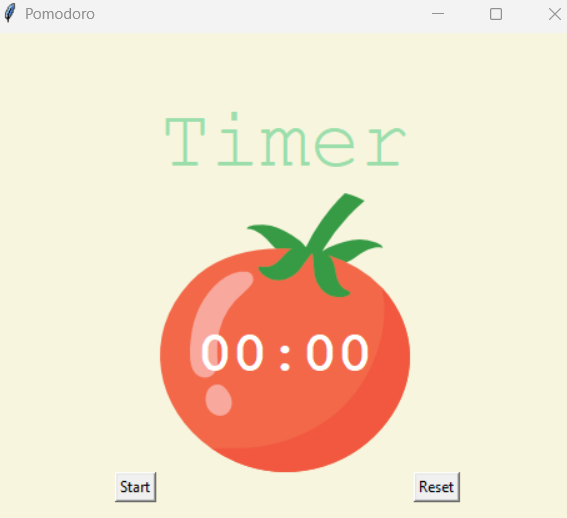